### Stwp 1: Import libraries. ###

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
print("✅ Step 1 Complete: All libraries imported successfully.")
print(f"TensorFlow Version: {tf.__version__}")

✅ Step 1 Complete: All libraries imported successfully.
TensorFlow Version: 2.17.0


### Step 2: Load Data ###

In [5]:
df_traffic = pd.read_csv("../Processed/Full_Traffic_With_Validity_Cleaned.csv")
df_traffic.head()

,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V88,V89,V90,V91,V92,V93,V94,V95,Daily_Total,Valid_Days
0,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/1/2006,...,34,28,28,14,14,15,12,5,4820,31
1,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/2/2006,...,32,25,21,22,17,7,8,7,6907,31
2,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/3/2006,...,40,33,32,46,11,11,11,7,7347,31
3,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/4/2006,...,40,26,34,24,25,15,8,8,7282,31
4,2200,UNION_RD N of MAROONDAH_HWY,046 H08,-37.81631,145.09812,10074,198,1,1,10/5/2006,...,38,47,31,26,22,15,14,9,7608,31


In [6]:
df_efficiency = pd.read_csv('../Processed/efficiency_stations_cleaned.csv')
df_efficiency.head()

,x,y,fid,objectid,tfm_id,tfm_desc,tfm_typ_de,movement_t,site_desc,road_nbr,...,time_categ,year_since,last_year,aadt_allve,aadt_truck,per_trucks,road_name,road_avg_aadt,efficiency_index,vs_average_pct
0,144.560081,-37.968598,45122,45324,42013,PRINCES FWY WB ON-RAMP FROM SOUTH RD,MIDBLOCK,On Ramp,PRINCES FWY ON-RAMP FROM SOUTH RD,7024,...,Greater than 10 Years,18,1998,40,0,0.21,160 SOUTH ROADB 2500F,40.0,1.00,0.0
1,145.088615,-37.881431,55947,55189,52075,MONASH FWY OUTBOUND OFFRAMP TO WARRIGAL RD,INTERSECTION,Off Ramp,SVO_Map_LTD:838||SITE DESC: MONASH FWY OUTBOUN...,7138,...,Between 5 and 10 Years,10,2006,13000,0,0.00,2000F 2070B,5350.0,2.43,143.0
2,145.090058,-37.882231,38735,38966,36894,S.E.ARTERIAL OFF RAMP NW OF WARRIGAL RD,INTERSECTION,Off Ramp,S.E.ARTERIAL SEBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,19,1997,8400,640,0.08,2000F 2070B,5350.0,1.57,57.0
3,145.088615,-37.881431,23193,23092,54241,S.E.ARTERIAL ON RAMP NW OF WARRIGAL RD,INTERSECTION,On Ramp,S.E.ARTERIAL NWBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,0,0,0,0,0.00,2000F 2070B,5350.0,0.00,-100.0
4,145.222981,-37.957762,6407,6604,9101,MONASH FWY OFF RAMP SEBD TO STUD RD,INTERSECTION,Off Ramp,MONASH FWY OFF RAMP STO STUD RD,7144,...,Between 5 and 10 Years,9,2007,8600,830,0.10,2000F 2090B,5625.0,1.53,53.0


In [7]:
print("\n--- Data Summary ---")
print(f"Traffic Shape: {df_traffic.shape}")
print(f"Efficiency Shape: {df_efficiency.shape}")


--- Data Summary ---
Traffic Shape: (2883, 108)
Efficiency Shape: (3503, 24)


### Step 3: EDA ###

In [8]:
#-- Data Transformation and Merging --
v_cols = [f'V{i:02d}' for i in range(96)]

#-- Melting the traffic volume columns. --#
df_eda = df_traffic.melt(
    id_vars=['SCATS Number', 'Date', 'Location'], 
    value_vars=v_cols, 
    var_name='Time_Slot', 
    value_name='Volume'
)

#-- Convert Date to datetime and extract time features for EDA. --#
df_eda['Date'] = pd.to_datetime(df_eda['Date'])
df_eda['Hour'] = df_eda['Time_Slot'].str.extract('(\d+)').astype(int) // 4
df_eda['DayOfWeek'] = df_eda['Date'].dt.dayofweek

print("✅ Data melted successfully. New shape:", df_eda.shape)
display(df_eda.head())

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_10612\950543701.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_eda['Hour'] = df_eda['Time_Slot'].str.extract('(\d+)').astype(int) // 4


✅ Data melted successfully. New shape: (276768, 7)


,SCATS Number,Date,Location,Time_Slot,Volume,Hour,DayOfWeek
0,2200,2006-10-01,UNION_RD N of MAROONDAH_HWY,V00,25,0,6
1,2200,2006-10-02,UNION_RD N of MAROONDAH_HWY,V00,4,0,0
2,2200,2006-10-03,UNION_RD N of MAROONDAH_HWY,V00,7,0,1
3,2200,2006-10-04,UNION_RD N of MAROONDAH_HWY,V00,3,0,2
4,2200,2006-10-05,UNION_RD N of MAROONDAH_HWY,V00,8,0,3


💾 Saved: EDA_Volume_Distribution.png


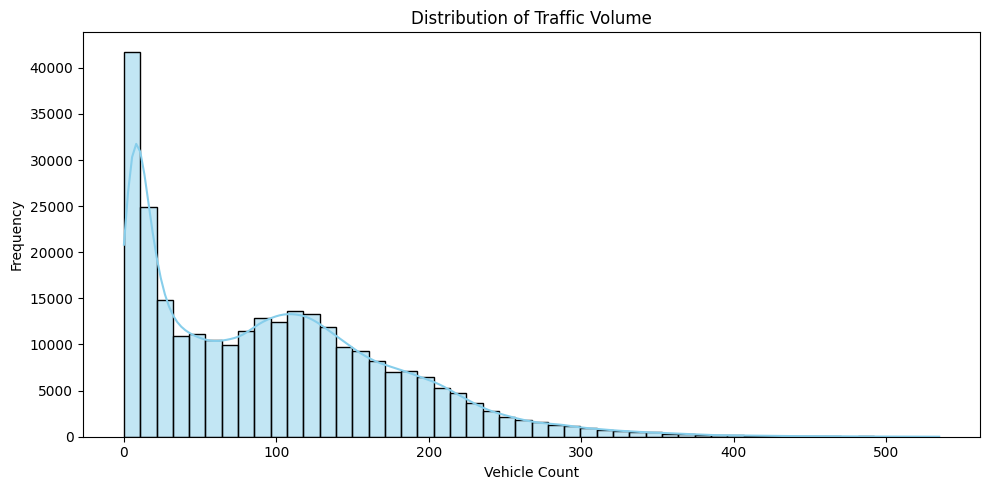

In [9]:
figures_dir = '../Figures'
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"✅ Created directory: {figures_dir}")

# Function to save plots to avoid repeating code
def save_eda_plot(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, filename))
    print(f"💾 Saved: {filename}")

# --- Plot 1: Traffic Volume Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(df_eda['Volume'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Traffic Volume')
plt.xlabel('Vehicle Count')
plt.ylabel('Frequency')
save_eda_plot('EDA_Volume_Distribution.png')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10612\114220743.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df_eda, x='Hour', y='Volume', ci='sd', color='orange')


💾 Saved: EDA_Hourly_Pattern.png


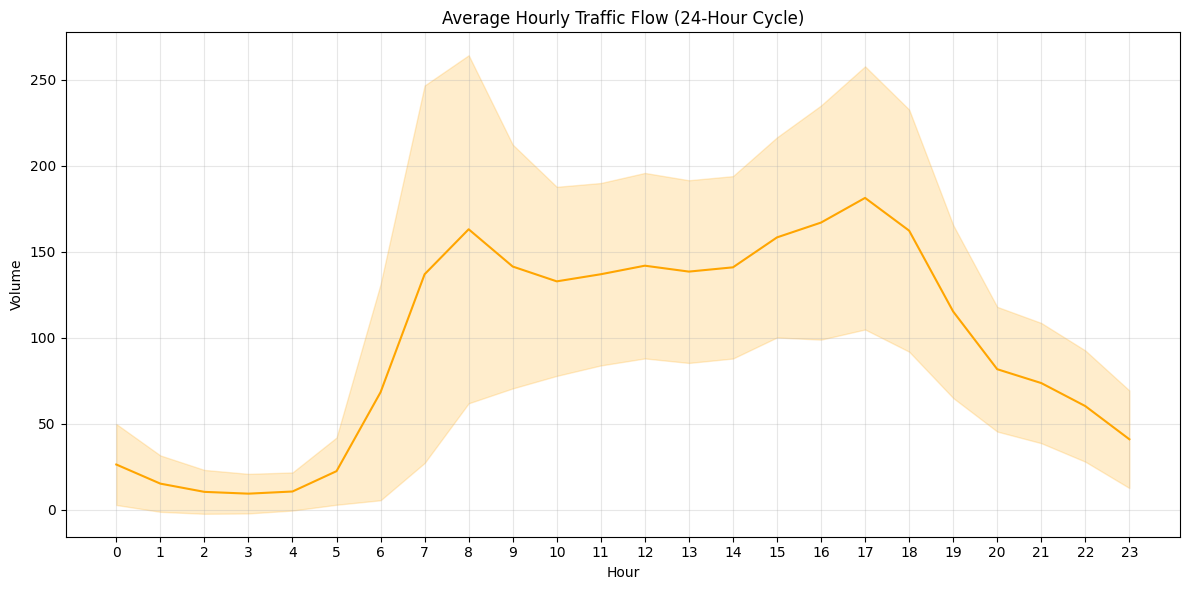

In [10]:
# --- Plot 2: Hourly Traffic Pattern (Seasonality) ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_eda, x='Hour', y='Volume', ci='sd', color='orange')
plt.title('Average Hourly Traffic Flow (24-Hour Cycle)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
save_eda_plot('EDA_Hourly_Pattern.png')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_10612\3776867925.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='DayOfWeek', y='Volume', palette='Set3')


💾 Saved: EDA_Weekly_Pattern.png


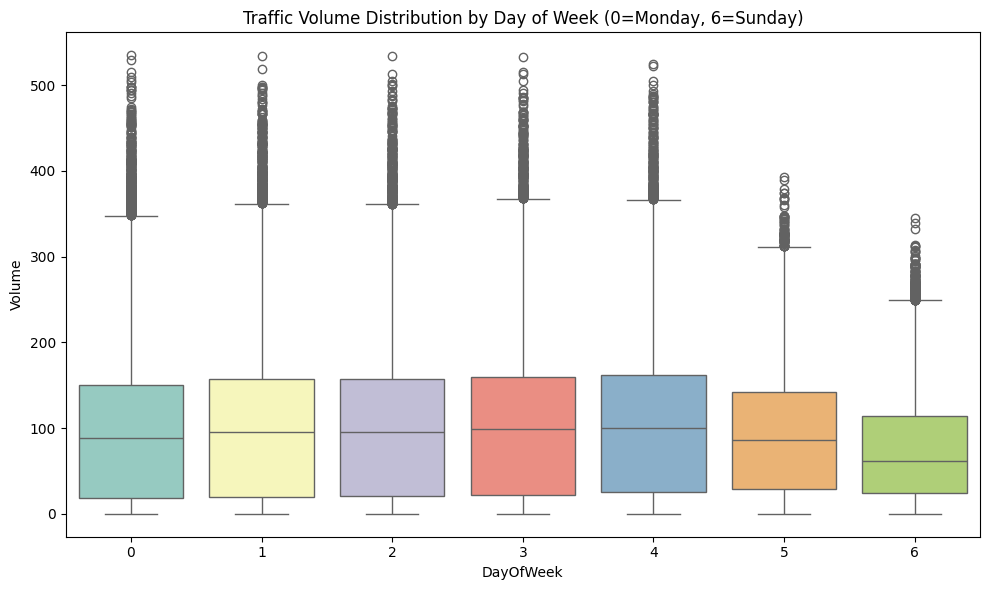

In [11]:
# --- Plot 3: Traffic Volume by Day of the Week ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eda, x='DayOfWeek', y='Volume', palette='Set3')
plt.title('Traffic Volume Distribution by Day of Week (0=Monday, 6=Sunday)')
save_eda_plot('EDA_Weekly_Pattern.png')
plt.show()

### Step 4: Data Processing and Feature Engineering ###

In [12]:
# --- STEP 4.1: FEATURE ENGINEERING ---
#-- Extracting time-based features and integrating road metadata. --#

df_final = df_eda.copy()

#-- 1. Extract Time Features. --#
df_final['Hour'] = df_eda['Time_Slot'].str.extract('(\d+)').astype(int) // 4
df_final['DayOfWeek'] = df_eda['Date'].dt.dayofweek
df_final['IsWeekend'] = df_final['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

#-- 2. Integrate Metadata (Using average from your efficiency file). --#
avg_eff = df_efficiency['efficiency_index'].mean()
avg_aadt = df_efficiency['road_avg_aadt'].mean()

df_final['Efficiency_Index'] = avg_eff
df_final['Road_Avg_AADT'] = avg_aadt

print("✅ Step 5.1 Complete: Features created.")
display(df_final[['Date', 'Time_Slot', 'Volume', 'Hour', 'IsWeekend']].head())


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_10612\2496186917.py:7: SyntaxWarning: invalid escape sequence '\d'
  df_final['Hour'] = df_eda['Time_Slot'].str.extract('(\d+)').astype(int) // 4


✅ Step 5.1 Complete: Features created.


,Date,Time_Slot,Volume,Hour,IsWeekend
0,2006-10-01,V00,25,0,1
1,2006-10-02,V00,4,0,0
2,2006-10-03,V00,7,0,0
3,2006-10-04,V00,3,0,0
4,2006-10-05,V00,8,0,0


In [13]:
# --- STEP 4.2: DATA SCALING ---
from sklearn.preprocessing import MinMaxScaler

#-- Selecting columns for training. --#
feature_cols = ['Volume', 'Efficiency_Index', 'Road_Avg_AADT', 'Hour', 'DayOfWeek', 'IsWeekend']
data_to_scale = df_final[feature_cols].values

#-- Initialize and fit Scaler. --#
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_to_scale)

print(f"✅ Step 5.2 Complete: Data scaled. Shape: {scaled_data.shape}")

✅ Step 5.2 Complete: Data scaled. Shape: (276768, 6)


In [14]:
# --- STEP 4.3: SLIDING WINDOW & SPLITTING ---

#-- 1. Function to create 96-step sequences. --#
def create_sequences(data, window_size=96):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # 24h history
        y.append(data[i, 0])              # Next volume value
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

#-- 2. Split into 80% Train and 20% Test. --#
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"✅ Step 4.3 Complete!")
print(f"Final Train Shape: {X_train.shape}") # Should be (Samples, 96, 6)
print(f"Final Test Shape: {X_test.shape}")

✅ Step 4.3 Complete!
Final Train Shape: (221337, 96, 6)
Final Test Shape: (55335, 96, 6)


### Step 5: Build and train Model ###

In [15]:
#-- Define GRU Model. --#
# 1. Initialize the Sequential model
model_gru = Sequential([
    # First GRU layer: return_sequences=True is needed to stack another GRU layer
    GRU(units=100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Dropout to prevent overfitting
    
    # Second GRU layer: return_sequences=False as it's the last recurrent layer
    GRU(units=50, return_sequences=False),
    Dropout(0.2),
    
    # Fully connected layers for the final prediction
    Dense(units=25, activation='relu'),
    Dense(units=1) # Output: Predicted Traffic Volume
])

# 2. Compile the model
# Using a slightly lower learning rate for stability
model_gru.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')

# 3. Show the model structure
model_gru.summary()

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 96, 100)        │        32,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,501 (220.71 KB)

 Trainable params: 56,501 (220.71 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# --- STEP 5.2: TRAINING CALLBACKS ---
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve for 10 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

print("✅ Early Stopping is ready. Model will stop if it stops learning.")

✅ Early Stopping is ready. Model will stop if it stops learning.


In [22]:
# --- STEP 5.3: EXECUTE TRAINING ---
print("🚀 GRU Training Started...")

history_gru = model_gru.fift(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("✅ Training session finished!")

🚀 GRU Training Started...
Epoch 1/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 403s 116ms/step - loss: 0.0056 - val_loss: 0.0016
Epoch 2/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 439s 127ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 3/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 554s 160ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 4/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 398s 115ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 5/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 343s 99ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 6/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 328s 95ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 7/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 332s 96ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 8/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 327s 94ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 9/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 321s 93ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 10/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 318s 92ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 11/50
3459/3459 ━━━━━━━━━━━━━━━━━━━━ 310s 90ms/step -

### Model Evaluation ###

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Predict on the test set
y_pred_scaled = model_gru.predict(X_test)

# 2. Inverse Transform to original scale (Vehicle Count)
def inverse_transform_volume(scaled_array):
    # Tạo mảng dummy 6 cột để scaler không báo lỗi
    dummy = np.zeros((len(scaled_array), 6))
    dummy[:, 0] = scaled_array.flatten() 
    unscaled = scaler.inverse_transform(dummy)
    return unscaled[:, 0]

y_pred_unscaled = inverse_transform_volume(y_pred_scaled)
y_test_unscaled = inverse_transform_volume(y_test)

# 3. Calculate Error Metrics
mae_gru = mean_absolute_error(y_test_unscaled, y_pred_unscaled)
rmse_gru = np.sqrt(mean_squared_error(y_test_unscaled, y_pred_unscaled))

print("============================================")
print("📊 GRU MODEL EVALUATION RESULTS")
print(f"Mean Absolute Error (MAE): {mae_gru:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gru:.4f}")
print("============================================")

1730/1730 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step
📊 GRU MODEL EVALUATION RESULTS
Mean Absolute Error (MAE): 13.7666
Root Mean Squared Error (RMSE): 19.9151


### Step 7: Generate test case ###

In [25]:
df_source = pd.read_csv('../Processed/Full_Traffic_With_Validity_Cleaned.csv')

total_rows = len(df_source)
start_index_20 = int(total_rows * 0.8)
df_20_percent = df_source.iloc[start_index_20:].copy()

test_case_dir = '../../TestCase/'
if not os.path.exists(test_case_dir):
    os.makedirs(test_case_dir)

test_names = ['GRUTest04', 'GRUTest05', 'GRUTest06']
indices = [0, len(df_20_percent)//2, len(df_20_percent)-10]

for i, start_pos in enumerate(indices):
    df_10_records = df_20_percent.iloc[start_pos : start_pos + 10]
    
    file_path = os.path.join(test_case_dir, f"{test_names[i]}.csv")
    df_10_records.to_csv(file_path, index=False)
    
    print(f"💾 Saved: {test_names[i]}.csv | Rows: {len(df_10_records)} | From index: {start_index_20 + start_pos}")

print(f"\n✅ Done! Have been created in {test_case_dir}")

💾 Saved: GRUTest04.csv | Rows: 10 | From index: 2306
💾 Saved: GRUTest05.csv | Rows: 10 | From index: 2594
💾 Saved: GRUTest06.csv | Rows: 10 | From index: 2873

✅ Done! Have been created in ../../TestCase/


### Step 8: Test ###

In [28]:
test_file_name = 'GRUTest05.csv'
test_file_path = f'../../TestCase/{test_file_name}'

df_test_raw = pd.read_csv(test_file_path)

v_cols = [f'V{i:02d}' for i in range(96)]
df_test_melted = df_test_raw.melt(
    id_vars=['Date', 'SCATS Number'], 
    value_vars=v_cols, 
    var_name='Time_Slot', 
    value_name='Actual_Volume'
)

df_test_melted['Hour'] = df_test_melted['Time_Slot'].str.extract('(\d+)').astype(int) // 4
df_test_melted['DayOfWeek'] = pd.to_datetime(df_test_melted['Date']).dt.dayofweek
df_test_melted['IsWeekend'] = df_test_melted['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df_test_melted['Efficiency_Index'] = avg_eff
df_test_melted['Road_Avg_AADT'] = avg_aadt

test_features = ['Actual_Volume', 'Efficiency_Index', 'Road_Avg_AADT', 'Hour', 'DayOfWeek', 'IsWeekend']
scaled_test_data = scaler.transform(df_test_melted[test_features])

print(f"✅ Loaded and Preprocessed {test_file_name}")
print(f"Total time slots to predict: {len(scaled_test_data)}")

✅ Loaded and Preprocessed GRUTest05.csv
Total time slots to predict: 960


<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\DELL\AppData\Local\Temp\ipykernel_16164\3928215584.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_test_melted['Hour'] = df_test_melted['Time_Slot'].str.extract('(\d+)').astype(int) // 4
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


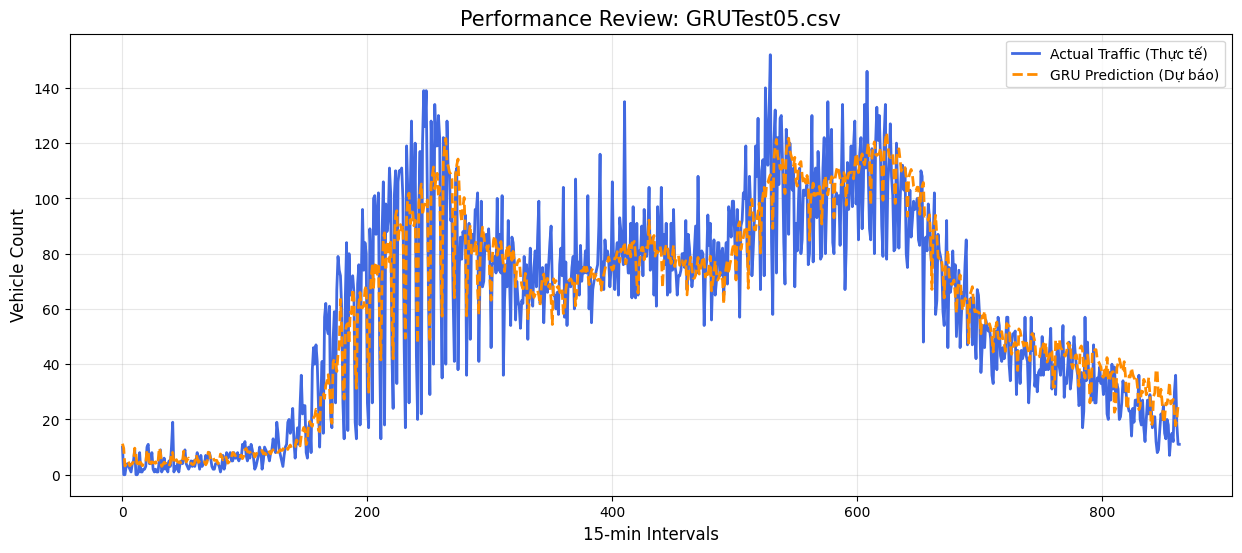

📊 Test Case MAE: 10.94 vehicles per 15-min


In [29]:
X_test_case, y_actual_scaled = [], []
window_size = 96

for i in range(window_size, len(scaled_test_data)):
    X_test_case.append(scaled_test_data[i-window_size:i, :])
    y_actual_scaled.append(scaled_test_data[i, 0])

X_test_case = np.array(X_test_case)

y_pred_scaled = model_gru.predict(X_test_case)

def get_unscaled(arr):
    dummy = np.zeros((len(arr), 6))
    dummy[:, 0] = arr.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

y_pred_final = get_unscaled(y_pred_scaled)
y_actual_final = get_unscaled(np.array(y_actual_scaled))

plt.figure(figsize=(15, 6))
plt.plot(y_actual_final, label='Actual Traffic (Thực tế)', color='royalblue', linewidth=2)
plt.plot(y_pred_final, label='GRU Prediction (Dự báo)', color='darkorange', linestyle='--', linewidth=2)

plt.title(f'Performance Review: {test_file_name}', fontsize=15)
plt.xlabel('15-min Intervals', fontsize=12)
plt.ylabel('Vehicle Count', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(f'../Figures/Result_{test_file_name.split(".")[0]}.png')
plt.show()

mae_test = np.mean(np.abs(y_pred_final - y_actual_final))
print(f"📊 Test Case MAE: {mae_test:.2f} vehicles per 15-min")

In [16]:
model_gru.save('../../Model/model_gru.keras')
print("✅ GRU model saved!")

✅ GRU model saved!
